# Seasonal Agriculture Performance Analysis
**VOIS AICTE Major Project | Batch 2026-2027**

This notebook analyzes seasonal variations in agricultural performance (yield, cost, profit, water usage, disease risk) across Kharif, Rabi and Zaid seasons using the provided dataset.

In [1]:
# Importing the libraries needed for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Understanding
First step is to load the dataset and just look around - how many rows/columns, what type of data is in each column, etc.

In [2]:
#loading the dataset
df=pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [3]:
#Extracting first 5 rows, just to see what our data looks like
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
#last 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
#checking the number of rows and columns
df.shape

(4000, 28)

Therefore, there are 4000 rows and 28 columns in the dataset.


In [6]:

#checking the column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
#now , to get the basic statistical information we use the describe function
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


we got to know the statistical data for the columns in our dataset


In [8]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [9]:
# Checking unique categories in key categorical columns
print("Seasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].unique())
print("Irrigation Methods:", df['Irrigation_Method'].unique())


Seasons: ['Kharif' 'Rabi' 'Zaid']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
States: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Irrigation Methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [10]:

#checking how many records exist per season
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [11]:
#categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## Data Cleaning
Checking for missing values and duplicate rows, and fixing them before doing any analysis.

In [12]:
# checking how many missing values are there in each column
df.isnull().sum()


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [13]:
# same thing but in percentage, easier to see how big the problem is
df.isnull().mean()*100


,0
Farm_ID,0.0
State,0.0
District,0.0
Crop,0.0
Season,0.0
Farm_Area_Hectares,0.0
Rainfall_mm,1.2
Avg_Temperature_C,0.0
Humidity_pct,0.0
Sunlight_Hours_Day,0.0


Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha are the columns with missing values. Filling these with the median value of the column (median is used instead of mean since it is not affected much by extreme values).

In [14]:
# filling missing rainfall values , soil moisture values and missing yeild value with thier median values respectively.
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())


In [15]:
#now checking again , whether the missing values are filled or not i.e the null count for these three columns should be 0.
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [16]:
# checking if there are any duplicate rows in the data
df.duplicated().sum()


np.int64(0)

## 4. Outlier Investigation
Before moving to deeper analysis, we check whether any numeric columns contain extreme
values (outliers) that could distort averages and charts. We use the **IQR (Interquartile
Range) method**: any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as a
potential outlier.

In [17]:
# Function-free IQR outlier check for the 3 most important numeric columns
for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {outlier_count} potential outliers (valid range: {round(lower_bound,2)} to {round(upper_bound,2)})")


Yield_Tonnes_Ha: 302 potential outliers (valid range: -1.62 to 5.5)
Profit_INR: 404 potential outliers (valid range: -696111.0 to 763567.0)
Rainfall_mm: 0 potential outliers (valid range: -319.02 to 1522.57)


**Observation:** `Profit_INR` and `Yield_Tonnes_Ha` show a noticeable number of extreme
values on the boxplots (seen earlier in the Season-wise comparison), while `Rainfall_mm` has
none. However, since these "outliers" represent genuinely poor or exceptionally good farm
performance (real losses and real bumper harvests) rather than data-entry errors, we choose
to **keep them in the dataset** rather than remove them — removing them would hide real
seasonal risk, which is exactly what this project is trying to study.


## 5. Univariate Analysis
Looking at individual variables one at a time to understand overall distribution before comparing across seasons.

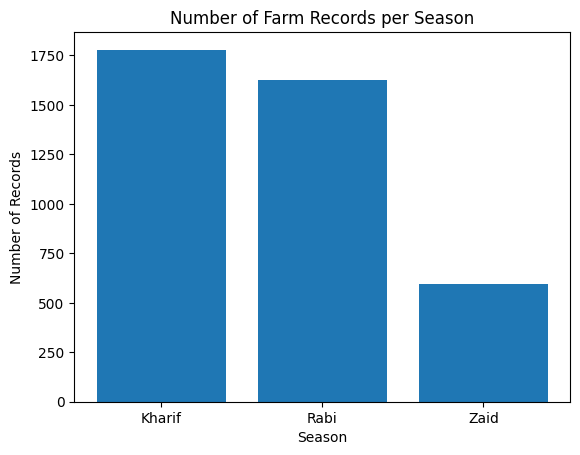

In [18]:
# Count the number of farm records in each season.
season_counts = df['Season'].value_counts()

plt.figure()
plt.bar(season_counts.index, season_counts.values)
plt.title('Number of Farm Records per Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.show()

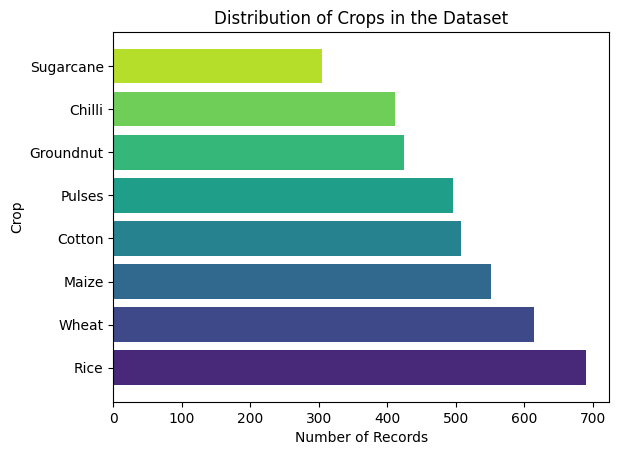

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many records belong to each crop.
crop_counts = df['Crop'].value_counts()

plt.figure()
colors = sns.color_palette('viridis', len(crop_counts))
plt.barh(crop_counts.index, crop_counts.values, color=colors)
plt.title('Distribution of Crops in the Dataset')
plt.xlabel('Number of Records')
plt.ylabel('Crop')
plt.show()

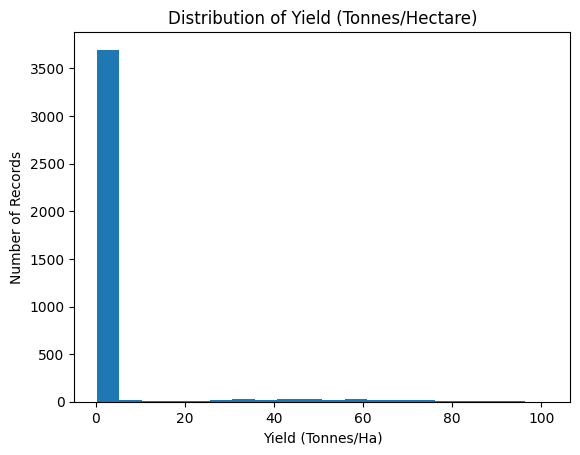

In [20]:
# Show how Yield is distributed across all farm records.
plt.figure()
plt.hist(df['Yield_Tonnes_Ha'], bins=20)
plt.title('Distribution of Yield (Tonnes/Hectare)')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Records')
plt.show()

## 6. Season-wise Performance Comparison
This is the core of the analysis — comparing agricultural performance metrics across Kharif, Rabi and Zaid.

i)Bivariate analysis


/tmp/ipykernel_1812/4164487186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=df, estimator=np.mean, palette='crest')


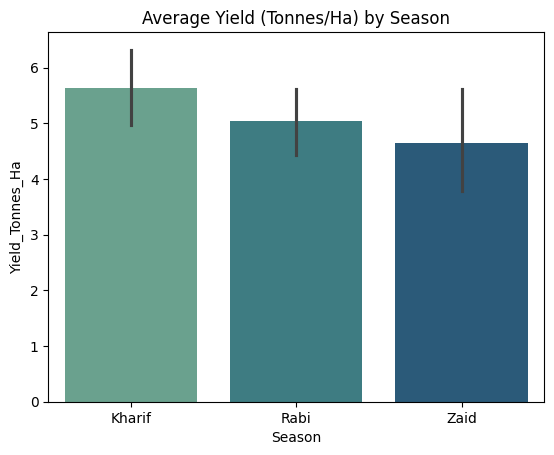

In [21]:
# Visual comparison of average Yield across seasons
plt.figure()
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=df, estimator=np.mean, palette='crest')
plt.title('Average Yield (Tonnes/Ha) by Season')
plt.show()

/tmp/ipykernel_1812/1276740825.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Profit_INR', data=df, palette='coolwarm')


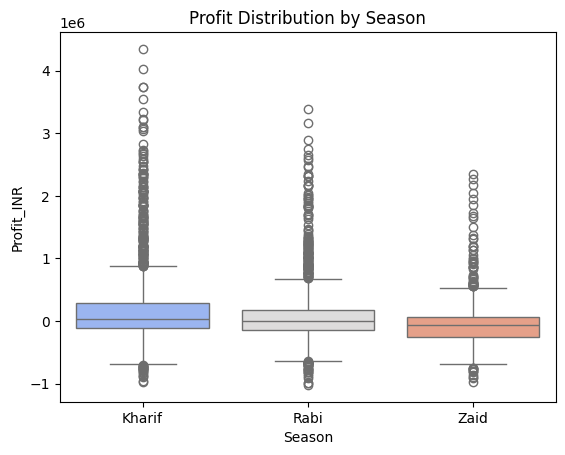

In [22]:
# A boxplot shows both the typical Profit and its spread in each season.
plt.figure()
sns.boxplot(x='Season', y='Profit_INR', data=df, palette='coolwarm')
plt.title('Profit Distribution by Season')
plt.show()

/tmp/ipykernel_1812/603387782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Rainfall_mm', data=df, ax=axes[0], palette='Blues')
/tmp/ipykernel_1812/603387782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Avg_Temperature_C', data=df, ax=axes[1], palette='Oranges')


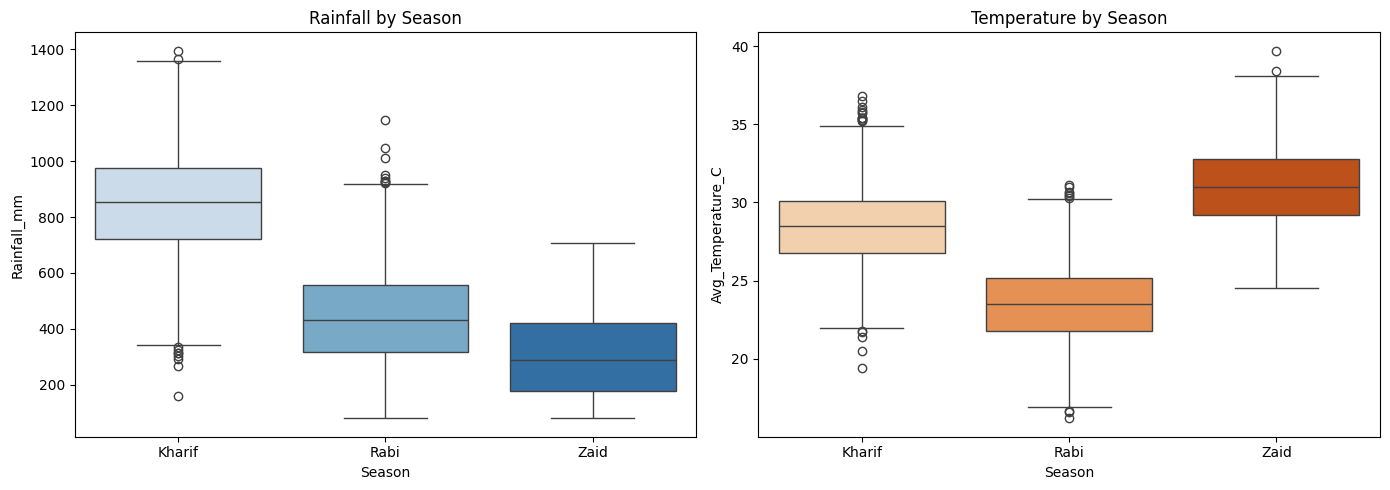

In [23]:
# Comparing environmental drivers - Rainfall and Temperature - across seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Season', y='Rainfall_mm', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Rainfall by Season')
sns.boxplot(x='Season', y='Avg_Temperature_C', data=df, ax=axes[1], palette='Oranges')
axes[1].set_title('Temperature by Season')
plt.tight_layout()
plt.show()

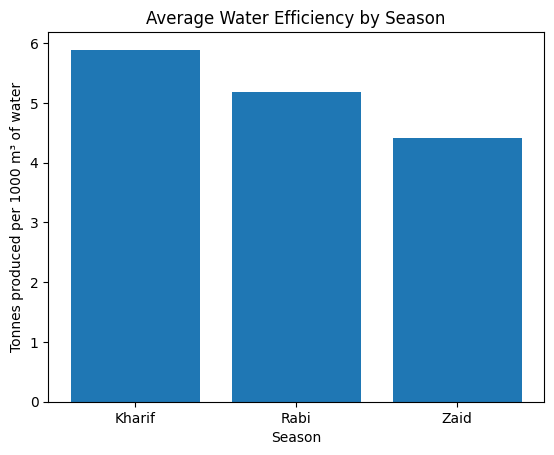

In [24]:
# Compare average water efficiency across seasons.
average_water_efficiency = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

plt.figure()
plt.bar(average_water_efficiency.index, average_water_efficiency.values)
plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes produced per 1000 m³ of water')
plt.show()

## 7. Crop and Season Relationship
Checking which crops are more common in which season, since this affects overall seasonal performance.

In [25]:
# Cross-tabulation to see how many farms of each crop fall in each season
crop_season = pd.crosstab(df['Crop'], df['Season'])
crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


i)Multivariate analysis

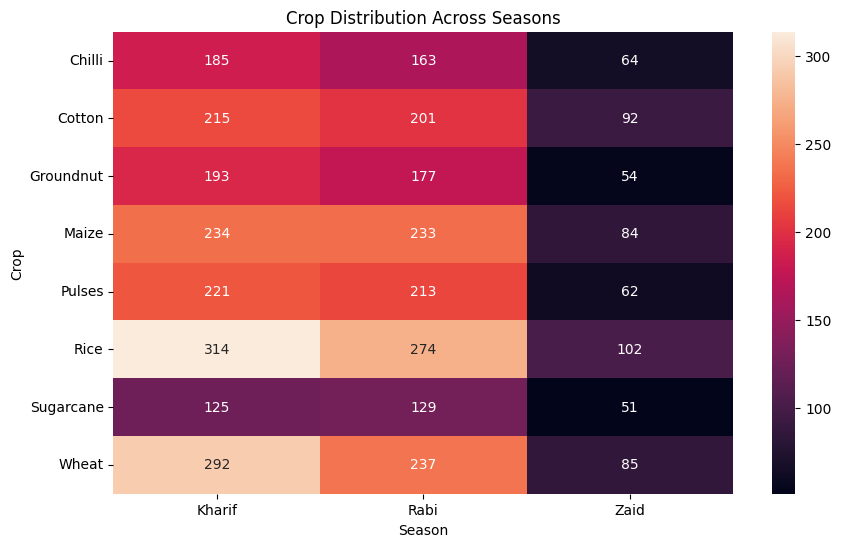

In [26]:
# Display the crop-season counts as a heatmap.
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season, annot=True, fmt='d')
plt.title('Crop Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()


## 8. Correlation Analysis
Identifying which numeric factors are most strongly related to Yield and Profit.

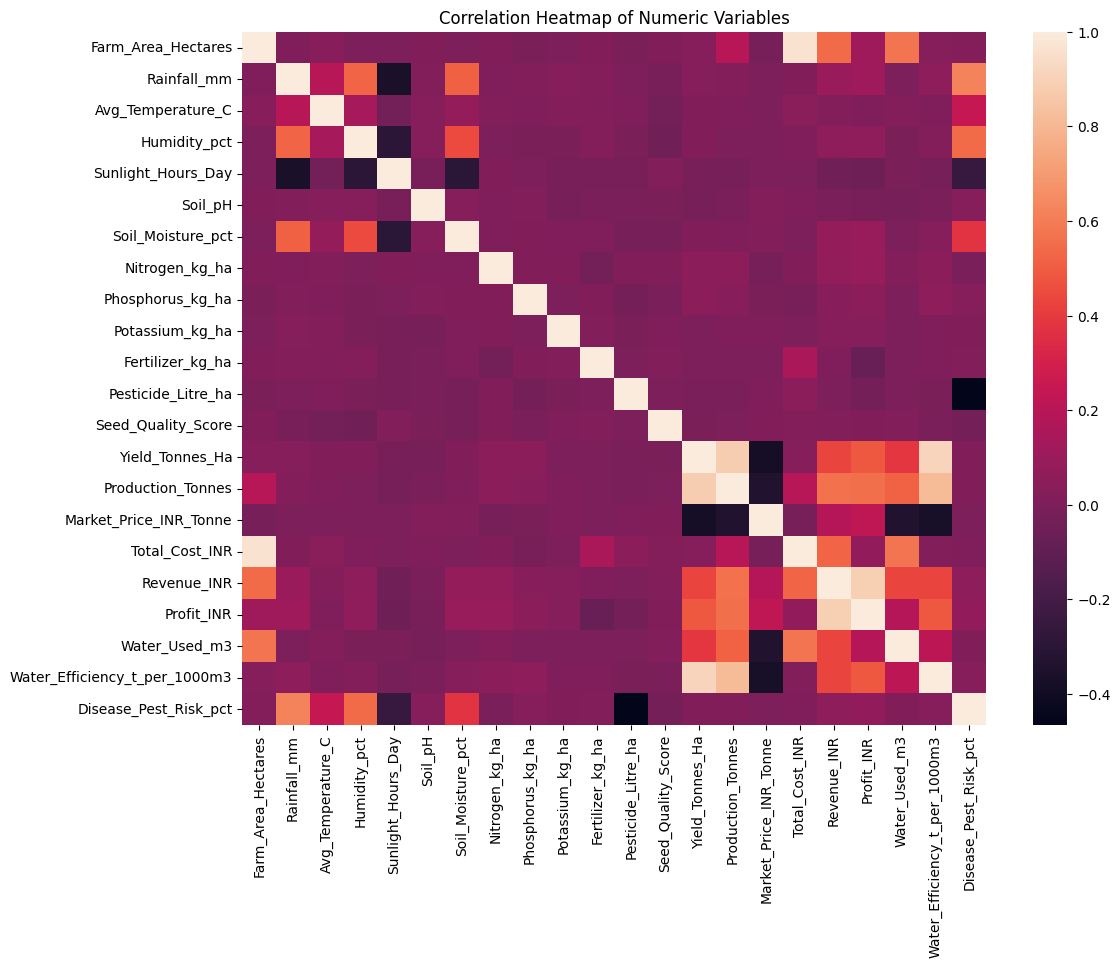

In [27]:
# Select only numeric columns and calculate their correlations.
# Correlation shows how two numeric variables move together.
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


In [28]:
# Find the variables that have the strongest positive or negative
# correlation with Yield.
yield_correlations = corr['Yield_Tonnes_Ha'].sort_values(ascending=False)

yield_correlations.head(8)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941


In [29]:
# Find the variables that have the strongest positive or negative
# correlation with Profit.
profit_correlations = corr['Profit_INR'].sort_values(ascending=False)

profit_correlations.head(8)

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241


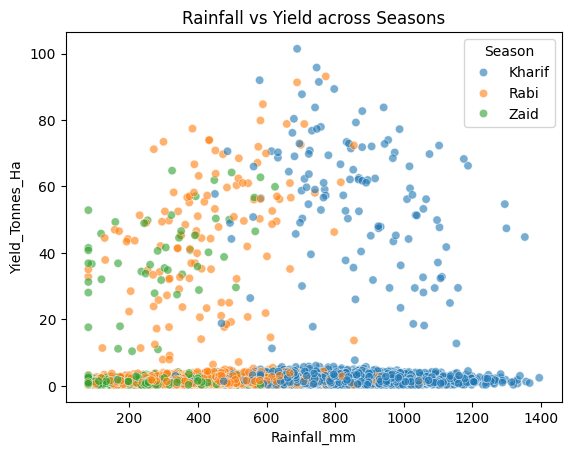

In [30]:
# Check whether Rainfall and Yield appear to be related.
# Different colours represent different seasons.
plt.figure()
sns.scatterplot(
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    data=df, alpha=0.6
)
plt.title('Rainfall vs Yield across Seasons')
plt.show()

## 9. Irrigation Method Analysis
Checking how the choice of irrigation method affects yield differently in different seasons.

In [31]:
# Checking which irrigation method is most commonly used in each season
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'])
irrigation_season


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


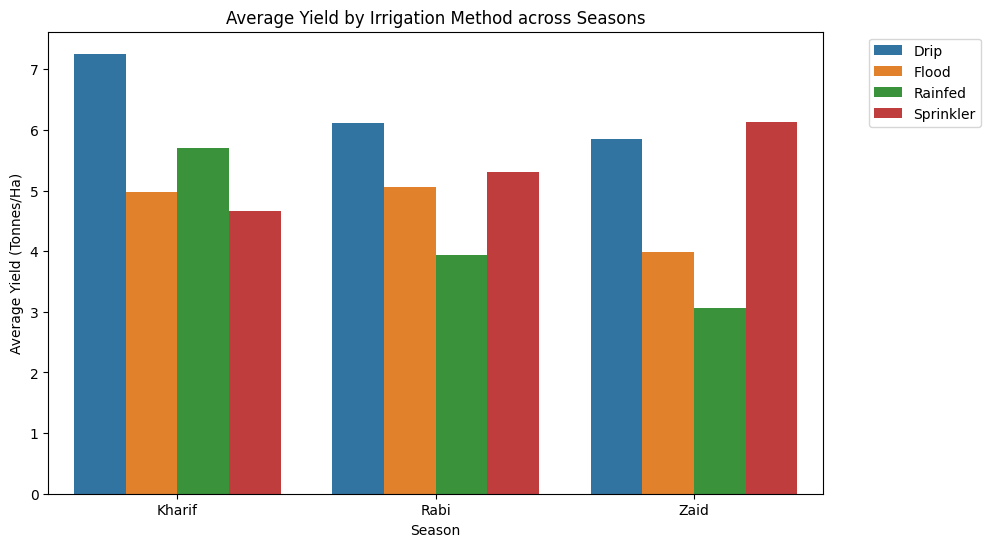

In [32]:
# Compare average Yield for each irrigation method within each season.
irrigation_yield = (
    df.groupby(['Season', 'Irrigation_Method'])['Yield_Tonnes_Ha']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Season',
    y='Yield_Tonnes_Ha',
    hue='Irrigation_Method',
    data=irrigation_yield
)
plt.title('Average Yield by Irrigation Method across Seasons')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## 10. Disease / Pest Risk Across Seasons
Checking whether crop health risk varies with seasonal conditions.

/tmp/ipykernel_1812/760153981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Season', y='Disease_Pest_Risk_pct', data=df, palette='Set2')


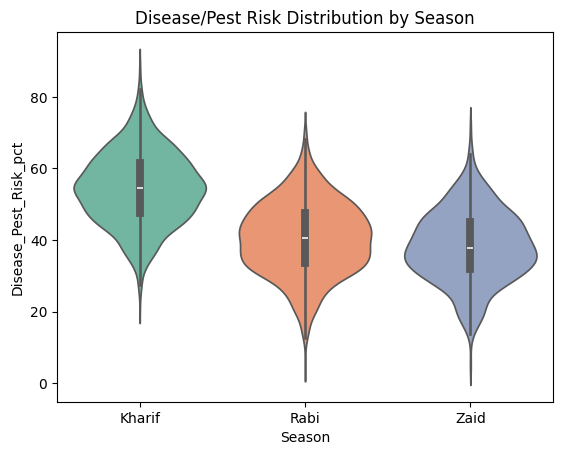

In [33]:
# Distribution of Disease/Pest Risk percentage by season
plt.figure()
sns.violinplot(x='Season', y='Disease_Pest_Risk_pct', data=df, palette='Set2')
plt.title('Disease/Pest Risk Distribution by Season')
plt.show()

## 11. Student-Designed Analysis
In this section, three additional analytical questions (framed independently, not directly
listed in the project brief) are explored using the same dataset.

### Student Analysis 1: Does farm size affect Yield per hectare?
**Question:** Do bigger farms (more hectares) produce a higher yield per hectare than smaller farms, or is yield independent of farm size?

Correlation between Farm Area and Yield: 0.03


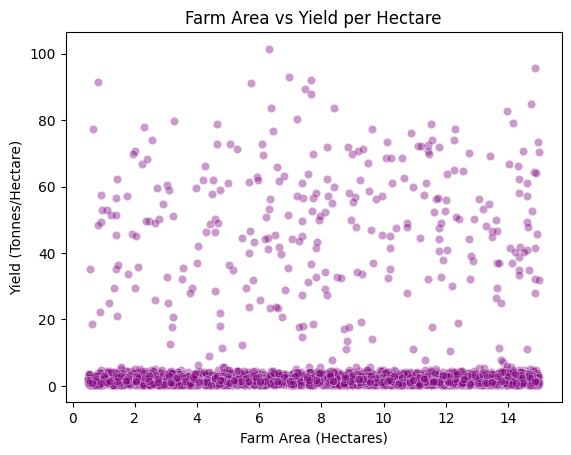

In [34]:
# Correlation between Farm Area and Yield
area_yield_corr = df['Farm_Area_Hectares'].corr(df['Yield_Tonnes_Ha'])
print("Correlation between Farm Area and Yield:", round(area_yield_corr, 3))

plt.figure()
sns.scatterplot(x='Farm_Area_Hectares', y='Yield_Tonnes_Ha', data=df, alpha=0.4, color='purple')
plt.title('Farm Area vs Yield per Hectare')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.show()


**Finding:** The correlation is very close to zero, and the scatter plot shows no visible
upward or downward trend. This means farm size does **not** meaningfully affect yield per
hectare in this dataset — small and large farms perform similarly on a per-hectare basis.

### Student Analysis 2: Does Seed Quality Score influence Yield?
**Question:** Farmers are often advised to use good-quality seeds. Does a higher Seed Quality Score actually translate into a higher yield in this dataset?

Correlation between Seed Quality Score and Yield: -0.007


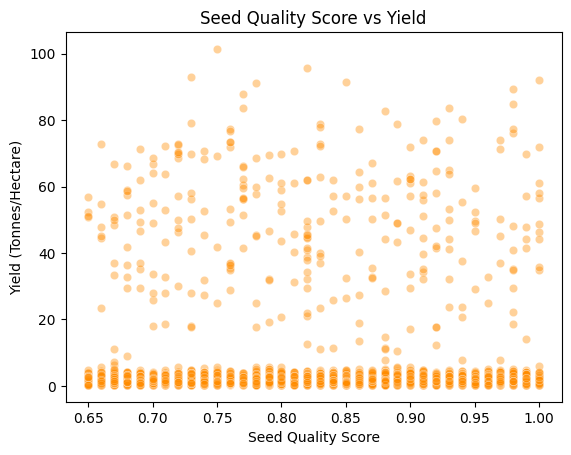

In [35]:
# Correlation between Seed Quality Score and Yield
seed_yield_corr = df['Seed_Quality_Score'].corr(df['Yield_Tonnes_Ha'])
print("Correlation between Seed Quality Score and Yield:", round(seed_yield_corr, 3))

plt.figure()
sns.scatterplot(x='Seed_Quality_Score', y='Yield_Tonnes_Ha', data=df, alpha=0.4, color='darkorange')
plt.title('Seed Quality Score vs Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.show()


**Finding:** The correlation here is also very close to zero. In this particular dataset,
Seed Quality Score does not show a clear relationship with Yield — other factors (season,
water efficiency) appear to matter more than seed quality alone.

### Student Analysis 3: Does farming cost explain why Zaid is the least profitable season?
**Question:** Zaid has the lowest average profit of the three seasons. Is this because Zaid also has a lower market price, or because it costs more to farm in Zaid?

In [36]:
# Compare average Total Cost and average Market Price across seasons
cost_price_by_season = df.groupby('Season')[['Total_Cost_INR', 'Market_Price_INR_Tonne']].mean().round(2)
cost_price_by_season


,Total_Cost_INR,Market_Price_INR_Tonne
Season,,
Kharif,531804.41,44850.91
Rabi,513836.58,44747.97
Zaid,543976.73,44212.03


/tmp/ipykernel_1812/1009918322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Total_Cost_INR', data=df, estimator=np.mean, palette='rocket')


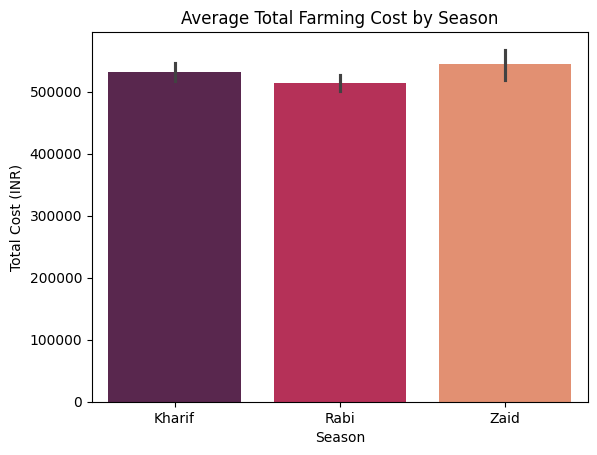

In [37]:
# Visualize average Total Cost by season
plt.figure()
sns.barplot(x='Season', y='Total_Cost_INR', data=df, estimator=np.mean, palette='rocket')
plt.title('Average Total Farming Cost by Season')
plt.ylabel('Total Cost (INR)')
plt.show()


**Finding:** The average Market Price is almost the same across all three seasons (within a
1-2% range), but the average Total Cost is highest in Zaid. This suggests that Zaid's lower
profit is driven mainly by **higher farming costs**, not by farmers getting a worse market
price for their produce.

## 12. Key Questions Answered
The project brief lists several key questions to investigate. Based on all the analysis
performed above, here are the answers.

**1. How does agricultural performance vary across seasons?**
Kharif has the highest average yield and by far the highest average profit; Zaid has the
lowest yield and the lowest (often negative) profit. Rabi sits in between.

**2. What major seasonal patterns can be observed?**
Rainfall, humidity and water efficiency are all highest in Kharif and lowest in Zaid, matching
Kharif being the monsoon season and Zaid being the hot, dry season.

**3. Which characteristics change between seasons?**
Rainfall, temperature, water usage/efficiency and total farming cost all change noticeably
between seasons, while seed quality and fertilizer usage stay fairly similar.

**4. What differences exist between agricultural activities in different seasons?**
Kharif depends more on natural rainfall; Zaid depends heavily on irrigation and has a higher
average farming cost for a similar yield.

**5. Are there noticeable variations in resource usage across seasons?**
Yes — water efficiency drops noticeably from Kharif to Zaid, meaning more water is used to
produce each tonne of crop in Zaid.

**6. Are there relationships between seasonal environmental conditions and agricultural performance?**
Yes, water efficiency and production volume show the strongest correlation with yield in the
correlation heatmap, while rainfall's direct correlation with yield is weaker but it still
shapes the season a farm belongs to.

**7. How do economic outcomes vary across seasons?**
Revenue and profit both fall from Kharif to Zaid. As shown in Student Analysis 3, this is
mainly because Zaid has a higher average farming cost, not a lower market price.

**8. Are some seasonal patterns consistent across different regions or categories?**
Yes — the crop-season heatmap shows that most crops individually follow a similar seasonal
yield pattern, rather than one or two crops driving the whole trend.

**9. Are there unusual or unexpected seasonal patterns?**
Farm size and seed quality score both show almost no relationship with yield (Student
Analyses 1 and 2), which is a bit unexpected since larger farms or better seeds are often
assumed to directly boost output.

**10. What insights can be derived from the observed seasonal differences?**
Kharif is the most reliable and profitable season, largely due to natural rainfall reducing
irrigation costs. Zaid is the riskiest season economically because irrigation-driven costs
rise while yield doesn't rise to match.

**11. What conclusions can reasonably be drawn from the available data?**
Season affects profit more clearly than it affects yield — the size of the season-wise profit
gap is much larger than the season-wise yield gap, and cost differences (not price
differences) appear to explain most of that gap.

**12. How could the findings support better seasonal agricultural planning?**
Prioritizing Kharif cultivation where feasible, improving irrigation efficiency for Zaid, and
offering cost-support or crop insurance specifically for Zaid-season farmers could reduce the
seasonal risk seen in this data.

## 13. Key Insights Summary

In [38]:
# Season-wise average performance summary - used as evidence for the insights below
seasonal_summary = df.groupby('Season')[[
    'Rainfall_mm', 'Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3',
    'Total_Cost_INR', 'Revenue_INR', 'Profit_INR'
]].mean().round(2)

print("SEASON-WISE AVERAGE PERFORMANCE:\n", seasonal_summary)


SEASON-WISE AVERAGE PERFORMANCE:
         Rainfall_mm  Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3  \
Season                                                                
Kharif       849.20             5.63                           5.89   
Rabi         437.62             5.04                           5.19   
Zaid         304.65             4.64                           4.41   

        Total_Cost_INR  Revenue_INR  Profit_INR  
Season                                           
Kharif       531804.41    710719.06   178914.65  
Rabi         513836.58    601526.05    87689.47  
Zaid         543976.73    519171.90   -24804.82  


Write **at least 8 meaningful insights** below. Each insight follows the structure:
**Observation → Evidence → Interpretation → Limitation.**

---

**Insight 1**
- **Observation:** Kharif has the highest average yield and profit of the three seasons.
- **Evidence:** Season-wise summary table and the "Average Yield by Season" / "Profit Distribution by Season" charts.
- **Interpretation:** Kharif's higher natural rainfall likely reduces irrigation dependency and cost, supporting better margins.
- **Limitation:** This is an association seen in the data, not a controlled experiment — other unmeasured factors (e.g. market demand timing) could also contribute.

**Insight 2**
- **Observation:** Zaid has the lowest average yield and, on average, the lowest profit — often negative.
- **Evidence:** Season-wise summary table; Student Analysis 3 (Total Cost by season).
- **Interpretation:** Zaid's higher total farming cost, combined with a similar market price to other seasons, is the main driver of its weaker profit.
- **Limitation:** The dataset does not separate cost into irrigation vs. labour vs. input categories, so the exact cost driver can't be confirmed precisely.

**Insight 3**
- **Observation:** Water-use efficiency is highest in Kharif and lowest in Zaid.
- **Evidence:** "Average Water Efficiency by Season" bar chart.
- **Interpretation:** Natural rainfall in Kharif likely supplements irrigation, producing more yield per unit of water used.
- **Limitation:** Water efficiency depends on irrigation method too, which varies farm to farm, so season alone doesn't fully explain it.

**Insight 4**
- **Observation:** Farm size (Farm_Area_Hectares) shows almost no correlation with Yield per hectare.
- **Evidence:** Student Analysis 1 — correlation value and scatter plot.
- **Interpretation:** Scaling up farm size does not automatically improve per-hectare productivity in this dataset.
- **Limitation:** Correlation only checks a straight-line relationship; a more complex (non-linear) relationship cannot be ruled out.

**Insight 5**
- **Observation:** Seed Quality Score shows almost no correlation with Yield.
- **Evidence:** Student Analysis 2 — correlation value and scatter plot.
- **Interpretation:** In this dataset, environmental and seasonal factors appear to matter more for yield than seed quality alone.
- **Limitation:** This does not mean seed quality is unimportant in general — it may simply not vary enough in this sample to show its effect.

**Insight 6**
- **Observation:** Rice, Wheat and Cotton are among the most commonly grown crops in the dataset.
- **Evidence:** "Distribution of Crops in the Dataset" bar chart.
- **Interpretation:** These crops may be more widely cultivated across the sampled regions and seasons.
- **Limitation:** This reflects the sample of farms in the dataset, not necessarily national cultivation patterns.

**Insight 7**
- **Observation:** Certain crops appear far more often in specific seasons (visible in the crop-season heatmap) rather than being spread evenly.
- **Evidence:** Crop Distribution Across Seasons heatmap.
- **Interpretation:** Crop choice and season are closely linked, which is expected agronomically (e.g. some crops are only grown in Kharif).
- **Limitation:** Because of this, season-wise averages are partly influenced by which crops are grown in that season, not season alone.

**Insight 8**
- **Observation:** Disease/Pest risk shows a visible spread difference across seasons in the violin plot.
- **Evidence:** "Disease/Pest Risk Distribution by Season" violin plot.
- **Interpretation:** Seasonal humidity and temperature conditions likely influence pest and disease pressure on crops.
- **Limitation:** The dataset only records a risk percentage, not the actual crop loss caused by disease/pests, so the real-world impact can't be quantified from this alone.

## Limitations of this Analysis
- This is a **cross-sectional dataset** (one snapshot), not multiple years of data, so we
  cannot confirm whether these seasonal patterns repeat year after year.
- All relationships discussed are **associations found in the data**, not proven cause-and-effect —
  we have not run controlled experiments to isolate the effect of one variable at a time.
- The dataset does not break down `Total_Cost_INR` into sub-categories (labour, irrigation,
  fertilizer, etc.), so exact cost drivers behind Zaid's lower profit are inferred, not directly measured.
- Farm-level factors not present in the dataset (soil type in detail, farmer experience,
  local market access) could also be influencing yield and profit, but are outside this analysis.

## 14. Conclusions & Recommendations

### Key Findings

- **Kharif** performed the best overall, with the highest average yield(5.6 t/ha) and profit(Rs1.79 lakh/farm).
- **Rabi** showed moderate and relatively stable performance.
- **Zaid** had the lowest economic performance, mainly due to higher farming costs despite a reasonably comparable yield.
- Overall, **season had a clearer effect on profit than on yield**, making economic factors important when comparing seasons.
- **Water efficiency and production volume** were strongly related to yield, while revenue and production volume were closely related to profit.
- Rice, Wheat, and Cotton were among the most commonly grown crops in the dataset.

### Recommendations

1. Focus on **Kharif cultivation and efficient water management** where conditions are favorable.
2. Try to **reduce irrigation and input costs during Zaid** season.
3. Encourage **water-efficient irrigation methods** to improve production.
4. Use **state-wise seasonal results** for better crop planning.
5. Plan pest and disease management according to the **seasonal risk patterns** found in the analysis.

## Project Checklist

- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records identified and handled
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] At least 3 student-designed analyses completed
- [x] At least 8 meaningful insights documented
- [x] Evidence-based recommendations provided
- [x] Limitations discussed
- [x] Final conclusion provided